<a href="https://colab.research.google.com/github/Anushriya3007/ANUSHRIYA-R_4NI23CI018_ML2LAB_E1/blob/main/Lab_program_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#bagging and boosting

First 5 rows of the dataset:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Dataset shape: (569, 31)

Target classes:
['malignant' 'benign']

Training samples: 455
Testing samples: 114

========== MODEL PERFORMANCE COMPARISON ==========


,Model,Accuracy,Precision,Recall,F1 Score
0,Bagging,0.938596,0.945205,0.958333,0.951724
1,Boosting,0.956140,0.946667,0.986111,0.965986



========== BAGGING CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        42
      benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114


========== BOOSTING CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


========== BAGGING CONFUSION MATRIX ==========
[[38  4]
 [ 3 69]]

========== BOOSTING CONFUSION MATRIX ==========
[[38  4]
 [ 1 71]]


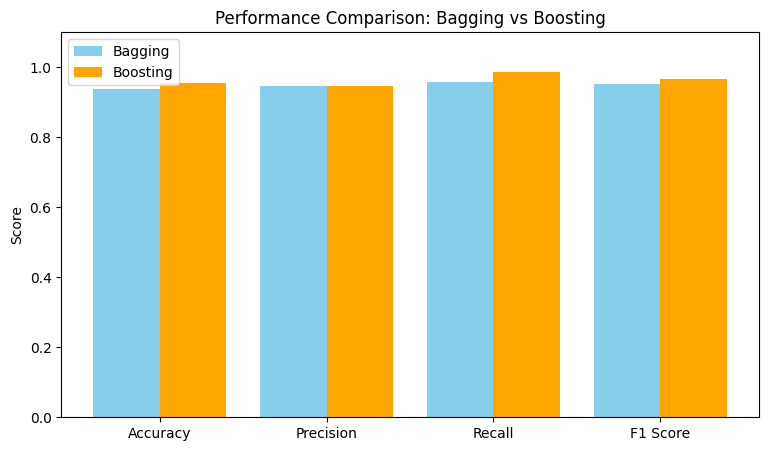

In [4]:
# ============================================================
# BAGGING AND BOOSTING FOR CLASSIFICATION
# ============================================================

# Step 1: Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# Step 2: Read the supervised dataset
# ============================================================

data = load_breast_cancer()

X = data.data
y = data.target

# Convert into DataFrame
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y

print("First 5 rows of the dataset:")
display(df.head())

print("\nDataset shape:", df.shape)

print("\nTarget classes:")
print(data.target_names)


# ============================================================
# Step 3: Split dataset into training and testing data
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# ============================================================
# Step 4: BAGGING
# ============================================================

base_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

bagging_model = BaggingClassifier(
    estimator=base_model,
    n_estimators=50,
    random_state=42
)

# Train the model
bagging_model.fit(X_train, y_train)

# Predict
bagging_pred = bagging_model.predict(X_test)


# ============================================================
# Step 5: BOOSTING
# ============================================================

boosting_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    random_state=42
)

# Train the model
boosting_model.fit(X_train, y_train)

# Predict
boosting_pred = boosting_model.predict(X_test)


# ============================================================
# Step 6: Calculate performance metrics
# ============================================================

# Bagging metrics
bagging_accuracy = accuracy_score(y_test, bagging_pred)
bagging_precision = precision_score(y_test, bagging_pred)
bagging_recall = recall_score(y_test, bagging_pred)
bagging_f1 = f1_score(y_test, bagging_pred)

# Boosting metrics
boosting_accuracy = accuracy_score(y_test, boosting_pred)
boosting_precision = precision_score(y_test, boosting_pred)
boosting_recall = recall_score(y_test, boosting_pred)
boosting_f1 = f1_score(y_test, boosting_pred)


# ============================================================
# Step 7: Display comparison
# ============================================================

results = pd.DataFrame({
    "Model": ["Bagging", "Boosting"],
    "Accuracy": [bagging_accuracy, boosting_accuracy],
    "Precision": [bagging_precision, boosting_precision],
    "Recall": [bagging_recall, boosting_recall],
    "F1 Score": [bagging_f1, boosting_f1]
})

print("\n========== MODEL PERFORMANCE COMPARISON ==========")
display(results)


# ============================================================
# Step 8: Classification reports
# ============================================================

print("\n========== BAGGING CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        bagging_pred,
        target_names=data.target_names
    )
)


print("\n========== BOOSTING CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        boosting_pred,
        target_names=data.target_names
    )
)


# ============================================================
# Step 9: Confusion matrices
# ============================================================

print("\n========== BAGGING CONFUSION MATRIX ==========")
print(confusion_matrix(y_test, bagging_pred))

print("\n========== BOOSTING CONFUSION MATRIX ==========")
print(confusion_matrix(y_test, boosting_pred))


# ============================================================
# Step 10: Plot comparison
# ============================================================

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

bagging_scores = [
    bagging_accuracy,
    bagging_precision,
    bagging_recall,
    bagging_f1
]

boosting_scores = [
    boosting_accuracy,
    boosting_precision,
    boosting_recall,
    boosting_f1
]

x = range(len(metrics))

plt.figure(figsize=(9, 5))

plt.bar(
    [i - 0.2 for i in x],
    bagging_scores,
    width=0.4,
    label="Bagging",
    color="skyblue"
)

plt.bar(
    [i + 0.2 for i in x],
    boosting_scores,
    width=0.4,
    label="Boosting",
    color="orange"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Performance Comparison: Bagging vs Boosting")
plt.ylim(0, 1.1)
plt.legend()

plt.show()
